# 02 - Feature Engineering

Turns the cleaned tables from notebook 01 into the single model-ready table at
`data/processed/model_data.csv`.

Two families of features are built here:

- **Context features** derived from the booking row itself - time, distance, route, conditions.
  Safe to use anywhere.
- **History features** describing the customer or driver. These are the delicate ones. The rate
  columns shipped in `customers.csv` and `drivers.csv` are whole-period aggregates that already
  include the row being predicted, so they are **replaced** with expanding prior-history features
  computed over strictly earlier bookings.


In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["figure.dpi"] = 110


In [2]:
import data_preprocessing as dp
import feature_engineering as fe

cleaned = dp.load_and_clean()
bookings = cleaned["bookings"]
print(f"Cleaned bookings: {bookings.shape[0]:,} rows x {bookings.shape[1]} columns")


Cleaned bookings: 100,000 rows x 23 columns


## 1. Time features

Everything derives from the single `booking_ts` timestamp built during cleaning.

In [3]:
frame = fe.add_time_parts(bookings)
frame = fe.add_rush_hour_flag(frame)
frame = fe.add_night_ride_flag(frame)
frame = fe.add_time_of_day_band(frame)

frame[["booking_ts", "hour_of_day", "day_of_week", "is_weekend",
       "rush_hour_flag", "is_night_ride", "time_of_day_band"]].head()


,booking_ts,hour_of_day,day_of_week,is_weekend,rush_hour_flag,is_night_ride,time_of_day_band
0,2025-12-11 00:07:00,0,Thursday,0,0,1,Night
1,2025-07-07 06:13:00,6,Monday,0,0,0,Morning
2,2025-08-23 08:53:00,8,Saturday,1,1,0,Morning
3,2025-04-12 10:25:00,10,Saturday,1,1,0,Morning
4,2025-08-23 00:08:00,0,Saturday,1,0,1,Night


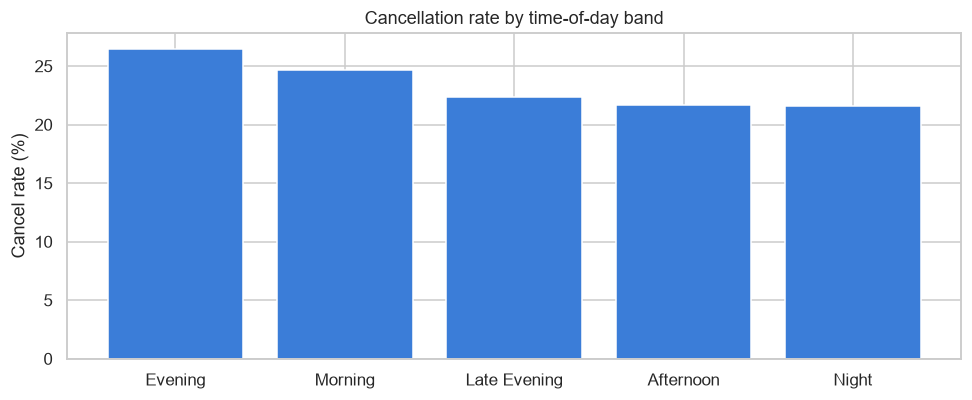

In [4]:
band_rates = fe.cancellation_rate_by(frame, "time_of_day_band")
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(band_rates["time_of_day_band"].astype(str), band_rates["cancel_rate"], color="#3B7DD8")
ax.set_title("Cancellation rate by time-of-day band"); ax.set_ylabel("Cancel rate (%)")
plt.tight_layout(); plt.show()


## 2. Trip context features

Distance bands, route identity, implied speed, surge bucket and the adverse-conditions interaction.

In [5]:
frame = fe.add_long_distance_flag(frame)
frame = fe.add_distance_band(frame)
frame = fe.add_city_route_pair(frame)
frame = fe.add_same_zone_flag(frame)
frame = fe.add_expected_speed(frame)
frame = fe.add_surge_bucket(frame)
frame = fe.add_adverse_conditions_flag(frame)
frame = fe.add_fare_ratios(frame)

frame[["ride_distance_km", "distance_band", "long_distance_flag", "expected_speed_kmph",
       "surge_bucket", "bad_weather_flag", "high_traffic_flag", "adverse_conditions_flag"]].head()


,ride_distance_km,distance_band,long_distance_flag,expected_speed_kmph,surge_bucket,bad_weather_flag,high_traffic_flag,adverse_conditions_flag
0,7.01,Medium,0,9.084233,Medium,1,1,1
1,9.67,Medium,0,13.325678,Medium,1,0,0
2,16.18,Long,1,19.995881,Medium,1,0,0
3,1.02,Short,0,13.275488,Medium,1,0,0
4,12.35,Medium,0,13.336933,Low,0,0,0


### The interaction that matters

`adverse_conditions_flag` marks bookings facing heavy rain **and** high traffic at once. Notebook 01
showed each factor matters separately; together they compound.


In [6]:
compare = fe.cancellation_rate_by(frame, "adverse_conditions_flag")
compare["label"] = compare["adverse_conditions_flag"].map({0: "Normal conditions", 1: "Heavy rain + high traffic"})
compare[["label", "rides", "cancel_rate", "incomplete_rate"]]


,label,rides,cancel_rate,incomplete_rate
1,Heavy rain + high traffic,11375,40.67,14.51
0,Normal conditions,88625,21.05,7.58


## 3. Composite scores

Driver reliability and customer loyalty, both scored 0-100 so they are directly comparable across the fleet.

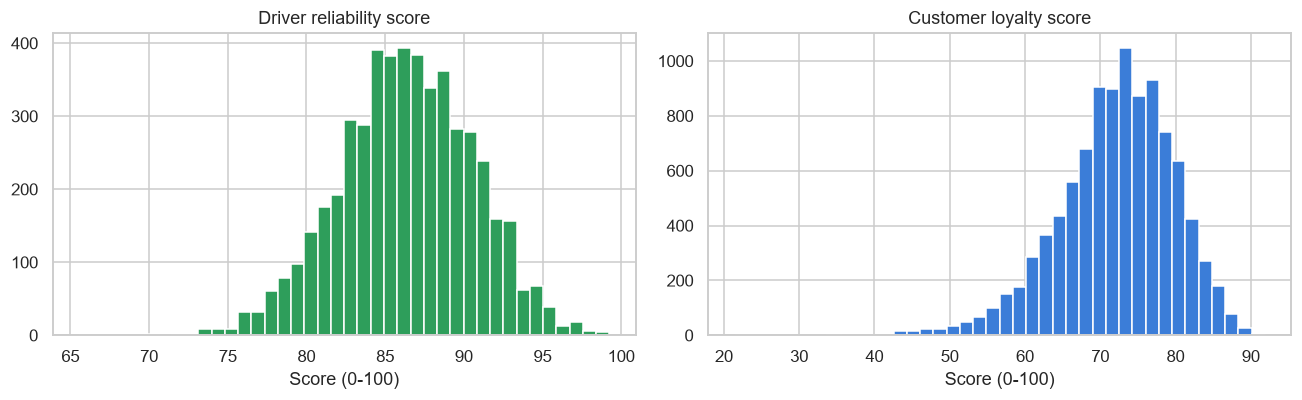

Driver reliability : mean 86.4, range 65.5-99.2
Customer loyalty   : mean 72.2, range 21.4-91.9


In [7]:
drivers = cleaned["drivers"].copy()
drivers["driver_reliability_score"] = fe.compute_driver_reliability_score(drivers)

customers = cleaned["customers"].copy()
customers["customer_loyalty_score"] = fe.compute_customer_loyalty_score(customers)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(drivers["driver_reliability_score"], bins=40, color="#2E9E5B")
axes[0].set_title("Driver reliability score"); axes[0].set_xlabel("Score (0-100)")
axes[1].hist(customers["customer_loyalty_score"], bins=40, color="#3B7DD8")
axes[1].set_title("Customer loyalty score"); axes[1].set_xlabel("Score (0-100)")
plt.tight_layout(); plt.show()

print(f"Driver reliability : mean {drivers['driver_reliability_score'].mean():.1f}, "
      f"range {drivers['driver_reliability_score'].min():.1f}-{drivers['driver_reliability_score'].max():.1f}")
print(f"Customer loyalty   : mean {customers['customer_loyalty_score'].mean():.1f}, "
      f"range {customers['customer_loyalty_score'].min():.1f}-{customers['customer_loyalty_score'].max():.1f}")


## 4. Merging the dimensions

Profile attributes only. The whole-period outcome aggregates are deliberately left behind.

In [8]:
frame = fe.merge_customer_features(frame, cleaned["customers"])
frame = fe.merge_driver_features(frame, cleaned["drivers"])
frame = fe.merge_time_features(frame, cleaned["time_features"])
frame = fe.merge_demand_features(frame, cleaned["location_demand"])
frame = fe.add_customer_tenure_bucket(frame)
frame = fe.add_demand_supply_ratio(frame)

print(f"After merges: {frame.shape[0]:,} rows x {frame.shape[1]} columns")
print("\nDeliberately NOT merged (whole-period aggregates of the target):")
for column in ["cancellation_rate", "cancelled_rides", "customer_cancel_flag",
               "delay_rate", "delay_count", "driver_delay_flag"]:
    print(f"  - {column}")


After merges: 100,000 rows x 62 columns

Deliberately NOT merged (whole-period aggregates of the target):
  - cancellation_rate
  - cancelled_rides
  - customer_cancel_flag
  - delay_rate
  - delay_count
  - driver_delay_flag


## 5. Prior-history features - the leakage-safe replacement

For each booking, these count only that customer's or driver's **strictly earlier** bookings.
A booking never contributes to its own predictors.

The first booking of any entity gets zero priors and a NaN rate. That NaN is meaningful - it says
"no history yet" - and the model pipeline imputes it rather than dropping the row.


In [9]:
frame = fe.add_prior_customer_history(frame)
frame = fe.add_prior_driver_history(frame)

history_columns = [c for c in frame.columns if c.startswith(("cust_prior", "drv_prior", "cust_is", "drv_is"))]
frame[history_columns].describe().T[["count", "mean", "std", "min", "max"]].round(4)


,count,mean,std,min,max
cust_prior_rides,100000.0,5.0071,3.6639,0.0,25.0
cust_prior_cancelled,100000.0,1.1672,1.2787,0.0,10.0
cust_prior_incomplete,100000.0,0.4164,0.6893,0.0,5.0
cust_prior_cancel_rate,90000.0,0.2327,0.2344,0.0,1.0
cust_prior_incomplete_rate,90000.0,0.0831,0.1527,0.0,1.0
cust_prior_completion_rate,90000.0,0.6842,0.2583,0.0,1.0
cust_is_first_ride,100000.0,0.1000,0.3000,0.0,1.0
drv_prior_rides,100000.0,10.0093,6.5963,0.0,37.0
drv_prior_cancelled,100000.0,2.3315,2.0422,0.0,14.0
drv_prior_incomplete,100000.0,0.8348,1.0276,0.0,7.0


### Proving the window is causal

One customer, ordered by time. Each row's `cust_prior_cancelled` must equal the number of cancellations in the rows strictly above it.

In [10]:
busiest = frame["customer_id"].value_counts().idxmax()
trace = (frame[frame["customer_id"] == busiest]
         .sort_values("booking_ts")
         [["booking_ts", "booking_status", "cust_prior_rides", "cust_prior_cancelled", "cust_prior_cancel_rate"]]
         .head(10).reset_index(drop=True))

expected = (trace["booking_status"].astype(str) == "Cancelled").cumsum().shift(1).fillna(0).astype(int)
trace["expected_prior_cancelled"] = expected
trace["matches"] = trace["cust_prior_cancelled"].values == expected.values
trace


,booking_ts,booking_status,cust_prior_rides,cust_prior_cancelled,cust_prior_cancel_rate,expected_prior_cancelled,matches
0,2025-01-23 07:20:00,Cancelled,0,0,NaN,0,True
1,2025-02-03 18:31:00,Completed,1,1,1.000000,1,True
2,2025-02-07 07:42:00,Completed,2,1,0.500000,1,True
3,2025-03-11 21:25:00,Completed,3,1,0.333333,1,True
4,2025-04-08 19:45:00,Completed,4,1,0.250000,1,True
5,2025-04-12 01:55:00,Completed,5,1,0.200000,1,True
6,2025-04-22 07:06:00,Cancelled,6,1,0.166667,1,True
7,2025-05-27 05:08:00,Completed,7,2,0.285714,2,True
8,2025-06-02 10:42:00,Completed,8,2,0.250000,2,True
9,2025-06-24 07:02:00,Cancelled,9,2,0.222222,2,True


In [11]:
assert trace["matches"].all(), "prior-history window is not causal"
print("Prior-history window verified causal: no booking contributes to its own predictors.")


Prior-history window verified causal: no booking contributes to its own predictors.


## 6. The finished feature table

In [12]:
print(f"Feature table: {frame.shape[0]:,} rows x {frame.shape[1]} columns\n")
kinds = frame.dtypes.astype(str).value_counts()
print("Column dtypes:"); print(kinds.to_string())


Feature table: 100,000 rows x 76 columns

Column dtypes:
float64           25
int64             23
category          12
str                9
string             3
int32              3
datetime64[us]     1


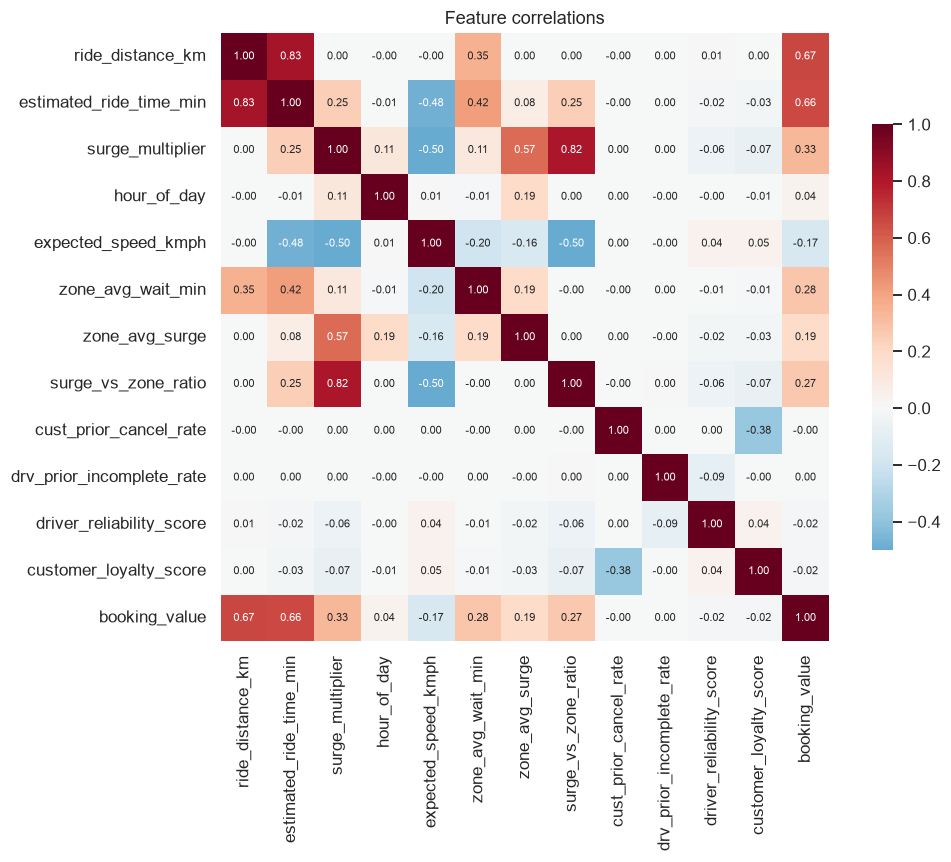

In [13]:
numeric_columns = [
    "ride_distance_km", "estimated_ride_time_min", "surge_multiplier", "hour_of_day",
    "expected_speed_kmph", "zone_avg_wait_min", "zone_avg_surge", "surge_vs_zone_ratio",
    "cust_prior_cancel_rate", "drv_prior_incomplete_rate", "driver_reliability_score",
    "customer_loyalty_score", "booking_value",
]
correlations = fe.correlation_matrix(frame, numeric_columns)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": 0.7}, annot_kws={"size": 7}, ax=ax)
ax.set_title("Feature correlations")
plt.tight_layout(); plt.show()


### Which features track the cancellation target?

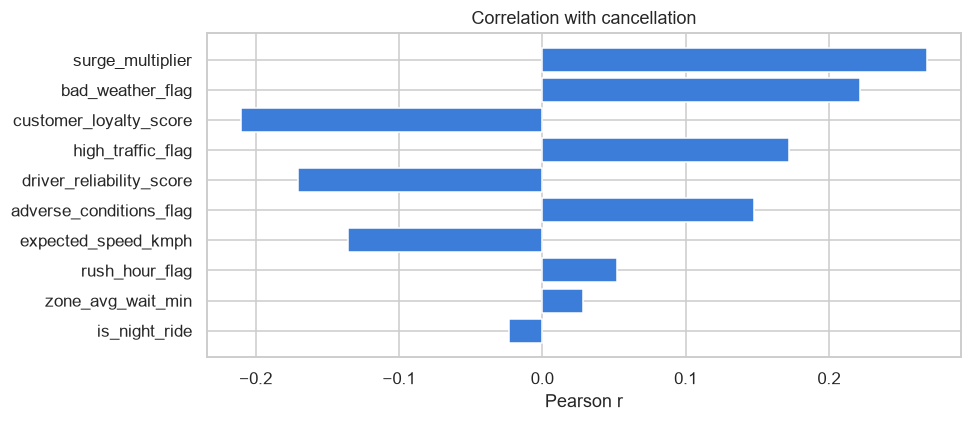

,feature,pearson,spearman,abs_pearson
0,surge_multiplier,0.2685,0.2749,0.2685
1,bad_weather_flag,0.2215,0.2215,0.2215
2,customer_loyalty_score,-0.2103,-0.2035,0.2103
3,high_traffic_flag,0.1723,0.1723,0.1723
4,driver_reliability_score,-0.1702,-0.1650,0.1702
5,adverse_conditions_flag,0.1474,0.1474,0.1474
6,expected_speed_kmph,-0.1354,-0.1390,0.1354
7,rush_hour_flag,0.0519,0.0519,0.0519
8,zone_avg_wait_min,0.0286,0.0271,0.0286
9,is_night_ride,-0.0234,-0.0234,0.0234


In [14]:
target = (frame["booking_status"].astype(str) == "Cancelled").astype(int)
scored = frame.assign(is_cancelled=target)
ranked = fe.correlation_with_target(
    scored,
    ["surge_multiplier", "high_traffic_flag", "bad_weather_flag", "adverse_conditions_flag",
     "ride_distance_km", "cust_prior_cancel_rate", "drv_prior_incomplete_rate",
     "rush_hour_flag", "is_night_ride", "customer_loyalty_score", "driver_reliability_score",
     "zone_avg_wait_min", "expected_speed_kmph"],
    "is_cancelled",
).head(10)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(ranked["feature"][::-1], ranked["pearson"][::-1], color="#3B7DD8")
ax.set_title("Correlation with cancellation"); ax.set_xlabel("Pearson r")
plt.tight_layout(); plt.show()
ranked


## 7. Persist the table

One file, `data/processed/model_data.csv`, consumed by notebook 03, the models and the dashboard.

In [15]:
path = dp.save_model_data(frame)
size_mb = path.stat().st_size / 1_048_576
print(f"Written: {path.name}  ({size_mb:.1f} MB, {len(frame):,} rows x {frame.shape[1]} columns)")


Written: model_data.csv  (49.5 MB, 100,000 rows x 76 columns)


## Conclusions

- **76 columns** in the finished table, built from 22 raw booking columns plus four merged dimensions.
- The three leaky column families identified in notebook 01 are excluded by construction, not by
  a later filter.
- **14 prior-history features** replace the whole-period aggregates, computed over strictly earlier
  bookings and verified causal above.
- `adverse_conditions_flag` captures the rain-and-traffic interaction that neither factor shows alone.

Next: **`03_model_training_evaluation.ipynb`** trains and evaluates the four models on this table.
